# Anomaly Detection - Transactions Ethereum

**Objectif :** Détecter des adresses Ethereum frauduleuses à partir de leur comportement transactionnel, en utilisant l'**Isolation Forest** (approche non supervisée).

**Pipeline :**
1. Chargement et description des données
2. Exploration (EDA)
3. Preprocessing
4. Modélisation (Isolation Forest)
5. Évaluation
6. Visualisation (t-SNE)

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
from category_encoders import TargetEncoder

import warnings
warnings.filterwarnings('ignore')

## 1. Chargement et description des données

Ce dataset contient des **transactions Ethereum** (blockchain). Chaque ligne représente une adresse.

### Variable cible
- `FLAG` : **0** = adresse légitime, **1** = adresse frauduleuse

### Transactions classiques (Ether)
| Colonne | Signification |
|---|---|
| `Avg_min_between_sent/received_tnx` | Temps moyen (min) entre chaque transaction envoyée/reçue |
| `Time_Diff_between_first_and_last` | Durée entre la 1re et la dernière transaction |
| `Sent_tnx` / `Received_Tnx` | Nombre de transactions envoyées / reçues |
| `Number_of_Created_Contracts` | Nombre de smart contracts créés |
| `Unique_Received_From/Sent_To_Addresses` | Nombre d'adresses distinctes en réception/envoi |
| `min/max/avg_value_received/sent` | Valeurs min/max/moyenne d'Ether reçu/envoyé |
| `total_Ether_sent/received` | Total d'Ether envoyé/reçu |
| `total_ether_balance` | Solde actuel en Ether |

### Transactions ERC20 (tokens)
Les **ERC20** sont des tokens construits sur Ethereum (comme USDT, LINK, UNI...). Ce ne sont pas des Ether mais des "sous-monnaies" du réseau.

| Colonne | Signification |
|---|---|
| `Total_ERC20_tnxs` | Nombre total de transactions ERC20 |
| `ERC20_total_Ether_received/sent` | Valeur totale en tokens reçue/envoyée |
| `ERC20_uniq_sent/rec_addr` | Nombre d'adresses uniques en envoi/réception |
| `ERC20_min/max/avg_val_rec/sent` | Valeur min/max/moyenne de tokens reçus/envoyés |
| `ERC20_most_sent/rec_token_type` | Le token le plus souvent envoyé/reçu (catégoriel) |

**En résumé :** les colonnes capturent le **comportement** d'une adresse Ethereum. L'idée est qu'une adresse frauduleuse aura un comportement **atypique**.

In [34]:
df = pd.read_csv('transaction_dataset.csv')
print(f"Shape : {df.shape}")
df.head()

Shape : (9841, 51)


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [35]:
df.dtypes

Unnamed: 0                                                int64
Index                                                     int64
Address                                                  object
FLAG                                                      int64
Avg min between sent tnx                                float64
Avg min between received tnx                            float64
Time Diff between first and last (Mins)                 float64
Sent tnx                                                  int64
Received Tnx                                              int64
Number of Created Contracts                               int64
Unique Received From Addresses                            int64
Unique Sent To Addresses                                  int64
min value received                                      float64
max value received                                      float64
avg val received                                        float64
min val sent                            

## 2. Exploration des données (EDA)

In [36]:
# Nettoyage des noms de colonnes : suppression des espaces en début/fin + remplacement des espaces par _
df.columns = df.columns.str.strip().str.replace(r'\b\s+\b', '_', regex=True)

In [37]:
# Distribution de la variable cible
print(df['FLAG'].value_counts())
print()
print(round(df['FLAG'].value_counts(normalize=True), 2))

FLAG
0    7662
1    2179
Name: count, dtype: int64

FLAG
0    0.78
1    0.22
Name: proportion, dtype: float64


In [38]:
# Vérification des doublons
print(f"Doublons sur la colonne Index : {df.duplicated(subset='Index').sum()}")
print(f"Lignes complètement identiques : {df.duplicated().sum()}")

Doublons sur la colonne Index : 5112
Lignes complètement identiques : 0


In [39]:
# Suppression des colonnes inutiles (identifiants)
df = df.drop(columns=['Unnamed: 0', 'Index', 'Address'])

In [40]:
# Identification des types de colonnes
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include='number').columns

print(f"{len(cat_cols)} colonnes catégorielles : {cat_cols.tolist()}")
print(f"{len(num_cols)} colonnes numériques")

2 colonnes catégorielles : ['ERC20_most_sent_token_type', 'ERC20_most_rec_token_type']
46 colonnes numériques


In [41]:
# Détail des colonnes catégorielles
for col in cat_cols:
    print(f"{col} : {df[col].nunique()} valeurs uniques, {df[col].isnull().sum()} valeurs manquantes")

ERC20_most_sent_token_type : 304 valeurs uniques, 2697 valeurs manquantes
ERC20_most_rec_token_type : 466 valeurs uniques, 871 valeurs manquantes


In [42]:
# Colonnes à variance nulle (constantes) → aucune information utile
constant_cols = num_cols[df[num_cols].var() == 0]
print(f"{len(constant_cols)} colonnes constantes : {constant_cols.tolist()}")

df = df.drop(columns=constant_cols)

7 colonnes constantes : ['ERC20_avg_time_between_sent_tnx', 'ERC20_avg_time_between_rec_tnx', 'ERC20_avg_time_between_rec_2_tnx', 'ERC20_avg_time_between_contract_tnx', 'ERC20_min_val_sent_contract', 'ERC20_max_val_sent_contract', 'ERC20_avg_val_sent_contract']


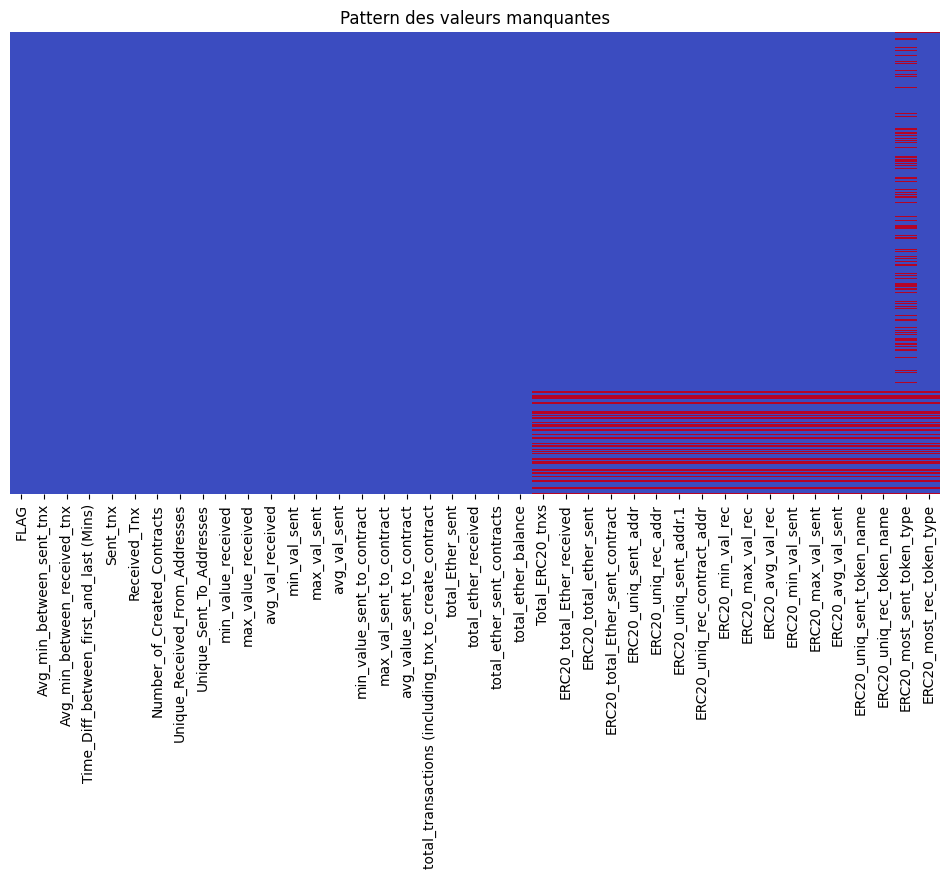

In [43]:
# Heatmap des valeurs manquantes
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cmap='coolwarm', cbar=False)
plt.yticks([])
plt.title('Pattern des valeurs manquantes')
plt.show()

In [44]:
# Analyse des valeurs manquantes vs FLAG
missing_mask = df.isnull().any(axis=1)
print(f"Lignes avec au moins 1 valeur manquante : {missing_mask.sum()}")
print()
print("Distribution FLAG parmi les lignes avec des manquants :")
print(round(df.loc[missing_mask, 'FLAG'].value_counts(normalize=True), 2))

Lignes avec au moins 1 valeur manquante : 2720

Distribution FLAG parmi les lignes avec des manquants :
FLAG
0    0.7
1    0.3
Name: proportion, dtype: float64


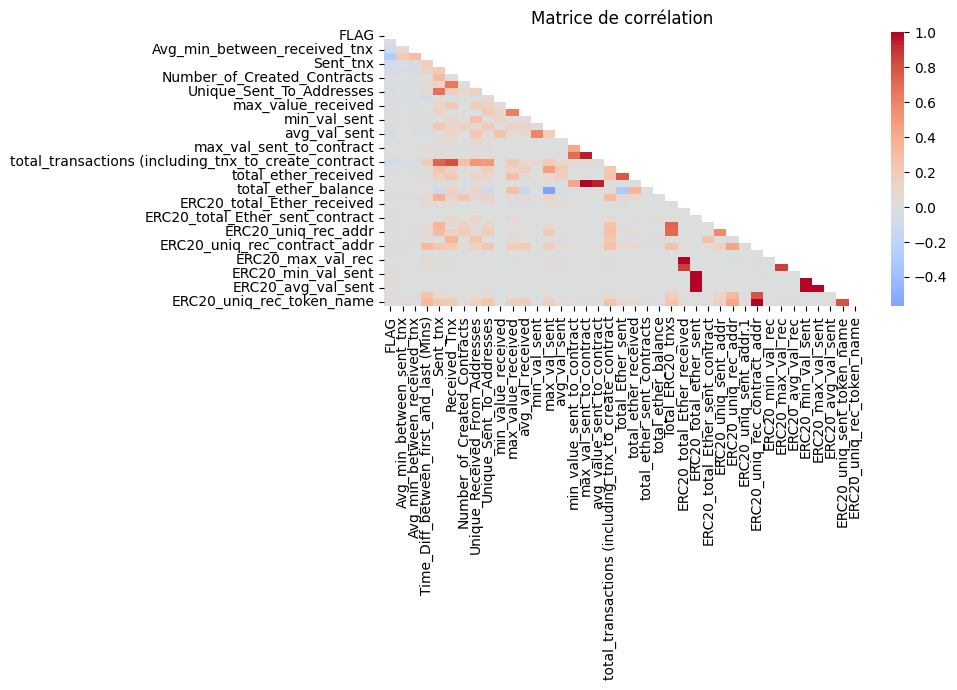

In [45]:
# Matrice de corrélation
plt.figure(figsize=(10, 7))
num_cols_updated = df.select_dtypes(include='number').columns
corr = df[num_cols_updated].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

## 3. Preprocessing

Étapes :
1. **Split train/test** (avant toute transformation pour éviter le data leakage)
2. **Imputation** des valeurs manquantes (médiane pour numériques, mode pour catégorielles)
3. **Suppression des features très corrélées** (seuil > 0.95)
4. **Target Encoding** des colonnes catégorielles
5. **RobustScaler** (normalisation robuste aux outliers)

In [46]:
# Split train/test AVANT toute transformation
X = df.drop('FLAG', axis=1)
y = df['FLAG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train : {X_train.shape}, Test : {X_test.shape}")

Train : (7872, 40), Test : (1969, 40)


In [47]:
# Imputation avec les stats du TRAIN uniquement (évite le data leakage)
num_features = X_train.select_dtypes(include='number').columns
cat_features = X_train.select_dtypes(include='object').columns

# Numériques : médiane du train
medians = X_train[num_features].median()
X_train[num_features] = X_train[num_features].fillna(medians)
X_test[num_features] = X_test[num_features].fillna(medians)

# Catégorielles : mode du train
for col in cat_features:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

print(f"Valeurs manquantes train : {X_train.isnull().sum().sum()}")
print(f"Valeurs manquantes test : {X_test.isnull().sum().sum()}")

Valeurs manquantes train : 0
Valeurs manquantes test : 0


### Suppression des features très corrélées

Deux colonnes très corrélées portent quasiment la même information. On supprime une des deux quand la corrélation dépasse **0.95**.

In [48]:
# Matrice de corrélation sur le train (numériques uniquement)
corr_matrix = X_train[num_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Colonnes avec corrélation > 0.95
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Colonnes supprimées ({len(to_drop)}) : {to_drop}")

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)
print(f"Features restantes : {X_train.shape[1]}")

Colonnes supprimées (7) : ['avg_value_sent_to_contract', 'total_ether_sent_contracts', 'ERC20_max_val_rec', 'ERC20_min_val_sent', 'ERC20_max_val_sent', 'ERC20_avg_val_sent', 'ERC20_uniq_rec_token_name']
Features restantes : 33


### Target Encoding

Remplace chaque catégorie par la **moyenne de `FLAG`** pour cette catégorie. Adapté ici car les 2 colonnes catégorielles ont trop de modalités (304 et 466) pour du one-hot encoding.

In [49]:
cat_features = X_train.select_dtypes(include='object').columns

encoder = TargetEncoder(cols=cat_features)
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

### RobustScaler

Normalise les données via la **médiane** et l'**IQR** (écart interquartile). Robuste aux valeurs extrêmes, ce qui est important pour un dataset de transactions.

In [50]:
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded),
    columns=X_train_encoded.columns,
    index=X_train_encoded.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded),
    columns=X_test_encoded.columns,
    index=X_test_encoded.index
)

print(f"Shape final : train {X_train_scaled.shape}, test {X_test_scaled.shape}")

Shape final : train (7872, 33), test (1969, 33)


## 4. Isolation Forest

**Principe :** les anomalies sont plus faciles à isoler que les points normaux.

L'algorithme construit des **arbres de décision aléatoires**. À chaque noeud, il choisit une variable et une coupure au hasard, jusqu'à isoler chaque point.

- **Point normal** (cluster dense) → chemin **long** → score bas
- **Point anormal** (isolé) → chemin **court** → score élevé

**Approche non supervisée :** le modèle s'entraîne **sans connaître `FLAG`**. On utilise `y_test` uniquement pour **évaluer** a posteriori.

In [64]:
# Entraînement de l'Isolation Forest
isolation_forest = IsolationForest(n_estimators= 100, max_samples= 1024,contamination=0.22, max_features= 1.0,random_state=42)
isolation_forest.fit(X_train_scaled)

# Prédictions : -1 = anomalie, 1 = normal
anomaly_train_pred = isolation_forest.predict(X_train_scaled)
anomaly_test_pred = isolation_forest.predict(X_test_scaled)

print(f"Anomalies détectées - Train : {np.sum(anomaly_train_pred == -1)}")
print(f"Anomalies détectées - Test  : {np.sum(anomaly_test_pred == -1)}")

Anomalies détectées - Train : 1681
Anomalies détectées - Test  : 407


## 5. Évaluation

Conversion des prédictions : IF prédit **-1** → **1** (fraude), IF prédit **1** → **0** (légitime).

In [65]:
# Convertir les prédictions IF (-1/1) en format FLAG (1/0)
y_test_pred = np.where(anomaly_test_pred == -1, 1, 0)

print("=== Résultats sur le TEST set ===")
print(classification_report(y_test, y_test_pred, target_names=['Légitime (0)', 'Fraude (1)']))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_test_pred))

=== Résultats sur le TEST set ===
              precision    recall  f1-score   support

Légitime (0)       0.86      0.87      0.86      1542
  Fraude (1)       0.50      0.48      0.49       427

    accuracy                           0.78      1969
   macro avg       0.68      0.67      0.68      1969
weighted avg       0.78      0.78      0.78      1969

Matrice de confusion :
[[1340  202]
 [ 222  205]]


## 5b. Tuning des hyperparamètres

On teste différentes combinaisons de :
- **`n_estimators`** : nombre d'arbres (plus = scores plus stables)
- **`max_samples`** : taille du sous-échantillon par arbre (plus = meilleure vision globale)
- **`max_features`** : proportion de features par arbre (moins = plus de diversité entre arbres)

In [62]:
from sklearn.metrics import f1_score

best_f1 = 0
best_params = {}
results = []

for n_est in [100, 200, 300]:
    for max_samp in [256, 512, 1024]:
        for max_feat in [0.5, 0.75, 1.0]:
            model = IsolationForest(
                n_estimators=n_est,
                max_samples=max_samp,
                max_features=max_feat,
                contamination=0.22,
                random_state=42
            )
            model.fit(X_train_scaled)
            preds = np.where(model.predict(X_test_scaled) == -1, 1, 0)
            f1 = f1_score(y_test, preds)
            results.append({'n_estimators': n_est, 'max_samples': max_samp, 'max_features': max_feat, 'f1_fraude': round(f1, 3)})

            if f1 > best_f1:
                best_f1 = f1
                best_params = {'n_estimators': n_est, 'max_samples': max_samp, 'max_features': max_feat}

print(f"Meilleur F1 fraude : {best_f1:.3f}")
print(f"Meilleurs paramètres : {best_params}")
print()

# Afficher le top 5
results_df = pd.DataFrame(results).sort_values('f1_fraude', ascending=False)
print("Top 5 combinaisons :")
print(results_df.head().to_string(index=False))

Meilleur F1 fraude : 0.492
Meilleurs paramètres : {'n_estimators': 100, 'max_samples': 1024, 'max_features': 1.0}

Top 5 combinaisons :
 n_estimators  max_samples  max_features  f1_fraude
          100         1024           1.0      0.492
          300         1024           1.0      0.469
          200         1024           1.0      0.410
          100          512           1.0      0.357
          100         1024           0.5      0.355


## 6. Visualisation t-SNE

**t-SNE** projette les features en **2D** en préservant les voisinages. Permet de visualiser si les anomalies détectées sont bien séparées des points normaux.

**Attention :** t-SNE sert uniquement à visualiser, pas à entraîner des modèles.

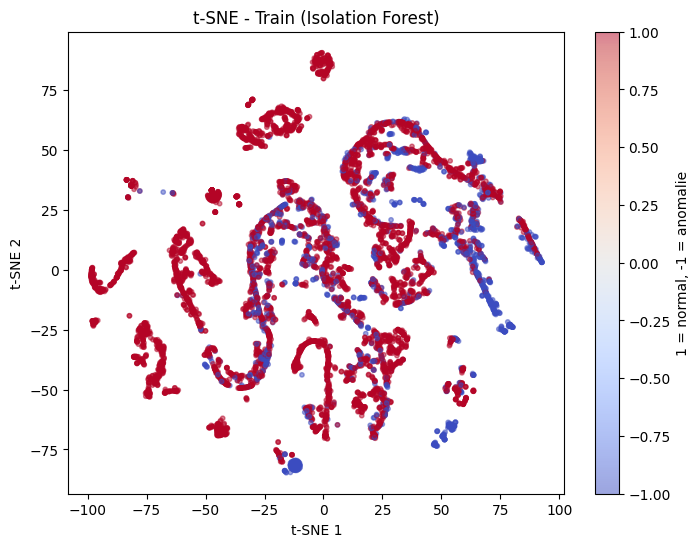

In [66]:
# t-SNE sur le train
tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train_encoded)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=anomaly_train_pred, cmap='coolwarm', alpha=0.5, s=10)
plt.colorbar(scatter, label='1 = normal, -1 = anomalie')
plt.title('t-SNE - Train (Isolation Forest)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

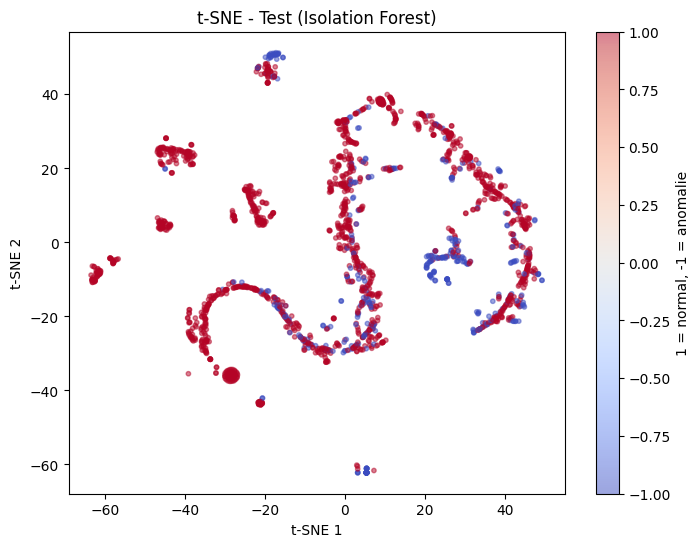

In [67]:
# t-SNE sur le test
X_test_tsne = tsne.fit_transform(X_test_encoded)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=anomaly_test_pred, cmap='coolwarm', alpha=0.5, s=10)
plt.colorbar(scatter, label='1 = normal, -1 = anomalie')
plt.title('t-SNE - Test (Isolation Forest)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()